In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('winequality-red.csv', sep=';')

In [5]:
display(df.head())
df.info()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [9]:
from sklearn.preprocessing import StandardScaler
X = df.drop('quality', axis=1)
y = df['quality']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
display(X_scaled_df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246
1,-0.298547,1.967442,-1.391472,0.043416,0.223875,0.872638,0.624363,0.028261,-0.719933,0.128950,-0.584777
2,-0.298547,1.297065,-1.186070,-0.169427,0.096353,-0.083669,0.229047,0.134264,-0.331177,-0.048089,-0.584777
3,1.654856,-1.384443,1.484154,-0.453218,-0.264960,0.107592,0.411500,0.664277,-0.979104,-0.461180,-0.584777
4,-0.528360,0.961877,-1.391472,-0.453218,-0.243707,-0.466193,-0.379133,0.558274,1.288643,-0.579207,-0.960246


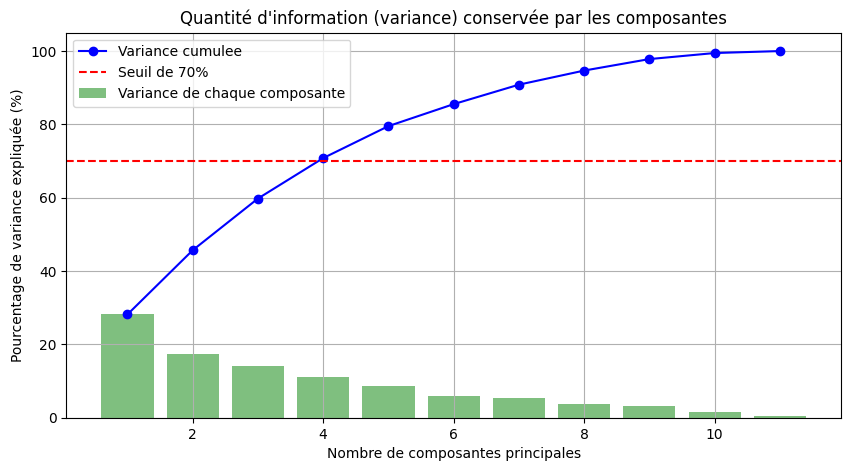

Information gardée avec 2 composantes (pour la 2D) : 45.7%
Information gardée avec 3 composantes (pour la 3D) : 59.8%


In [11]:
from sklearn.decomposition import PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled_df)
variance_ratio = pca.explained_variance_ratio_* 100
variance_cumulee = np.cumsum(variance_ratio)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(variance_ratio) +1), variance_cumulee, marker='o', linestyle='-', color='b', label='Variance cumulee')
plt.bar(range(1, len(variance_ratio) +1), variance_ratio, alpha=0.5, color='g', label='Variance de chaque composante')

plt.title("Quantité d'information (variance) conservée par les composantes")
plt.xlabel("Nombre de composantes principales")
plt.ylabel("Pourcentage de variance expliquée (%)")
plt.axhline(y=70, color='r', linestyle='--', label='Seuil de 70%')
plt.legend()
plt.grid(True)
plt.show()

print(f"Information gardée avec 2 composantes (pour la 2D) : {variance_cumulee[1]:.1f}%")
print(f"Information gardée avec 3 composantes (pour la 3D) : {variance_cumulee[2]:.1f}%")

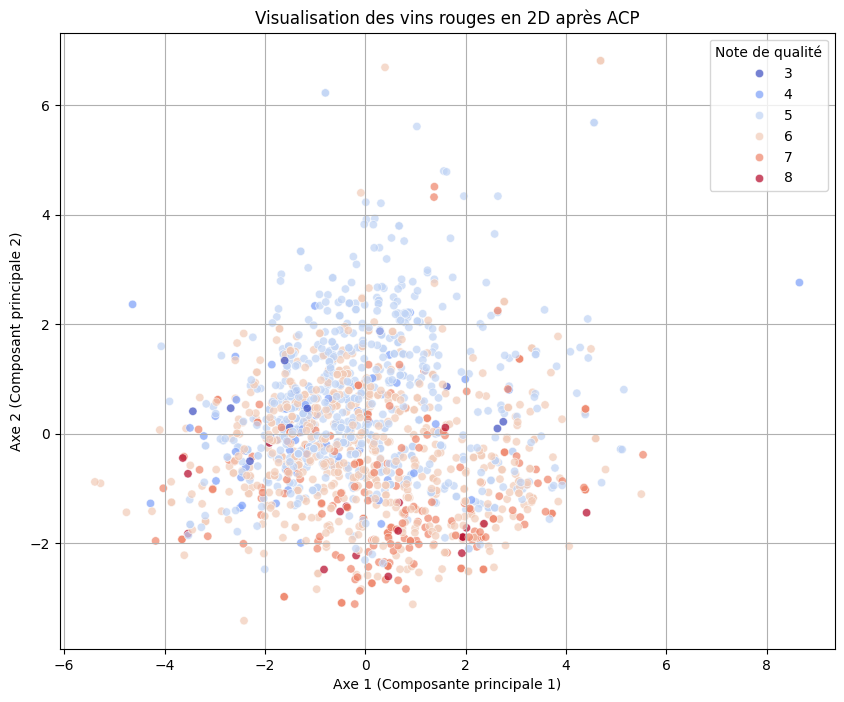

In [16]:
df_pca2D = pd.DataFrame(data=X_pca[:, :2], columns=['PC1', 'PC2'])

df_pca2D['qualité'] = y.values

plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='qualité', palette='coolwarm', data=df_pca2D, alpha=0.7)

plt.title("Visualisation des vins rouges en 2D après ACP")
plt.xlabel("Axe 1 (Composante principale 1)")
plt.ylabel("Axe 2 (Composant principale 2)")

plt.legend(title='Note de qualité')
plt.grid(True)
plt.show()

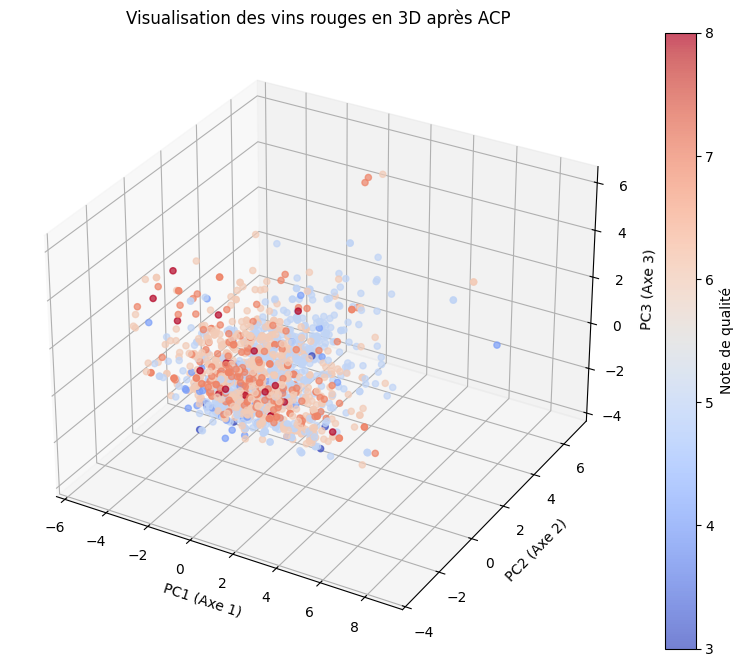

In [19]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=y, cmap='coolwarm', alpha=0.7)

ax.set_title("Visualisation des vins rouges en 3D après ACP")
ax.set_xlabel("PC1 (Axe 1)")
ax.set_ylabel("PC2 (Axe 2)")
ax.set_zlabel("PC3 (Axe 3)")

cbar = plt.colorbar(scatter)
cbar.set_label('Note de qualité')

plt.show()

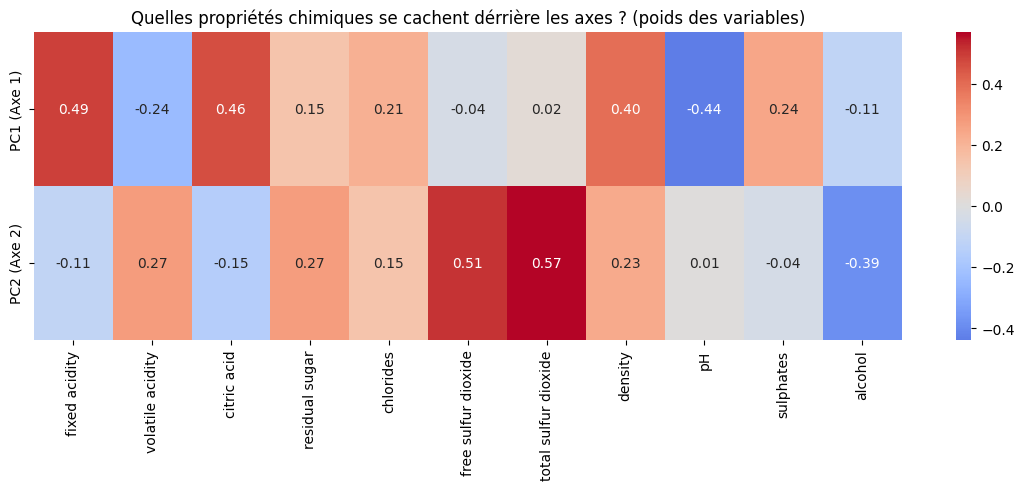

In [22]:
poids = pca.components_[:2, :]

df_loadings = pd.DataFrame(poids, columns=X.columns, index=['PC1 (Axe 1)', 'PC2 (Axe 2)'])
plt.figure(figsize=(14, 4))
sns.heatmap(df_loadings, annot=True, cmap='coolwarm', fmt=".2f", center=0)

plt.title("Quelles propriétés chimiques se cachent dérrière les axes ? (poids des variables)")
plt.show()

1. L'axe 1 (PC1) :
Cet axe regroupe l'acidité fixe, l'acide citrique et le pH (plus le pH est bas, plus le vin est acide, c'est pour ça que son score est de -0.44 alors que les autres sont positifs).

Recommandation : Cet axe permet de segmenter les clients qui aiment les vins vifs, frais et structurés, par rapport à ceux qui préfèrent des vins plus ronds et moins mordants.

2. L'axe 2 (PC2) :
Cet axe est presque à 100 % dédié au dioxyde de soufre (les sulfites).

Recommandation : Aujourd'hui, beaucoup de consommateurs cherchent des vins "nature" ou sans sulfites ajoutés. L'entreprise peut utiliser cet axe pour identifier rapidement les vins qui correspondent à cette clientèle spécifique (les vins situés très bas sur cet Axe 2).